In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy


from scipy.optimize import curve_fit

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [43]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [44]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)
print("shotnoise", Pk_sum10.attrs["shotnoise"])

shotnoise 304.0903879154701


In [12]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM11.0-11.1.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110_group = pickle.load(f)
print("shotnoise", Pk110_group.attrs["shotnoise"])

shotnoise 286.3949289238728


In [13]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM11.0-11.1.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110_gal = pickle.load(f)
print("shotnoise", Pk110_gal.attrs["shotnoise"])

shotnoise 262.72067788705453


In [19]:
def W_R(k, R=1):
    R = 2*R
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [20]:
def V_excl(R=1):
    R = 2*R
    return (4*np.pi*R**3)/3

In [21]:
def pk_random(k, R):
    result2 = -V_excl(R)*W_R(k,R)
    return result2

In [24]:
def kernel_lin(ks, R=1, nbins=100):
    dx = 2*R
    results = []
    r = np.linspace(0, dx, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [30]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(0, dx, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [16]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

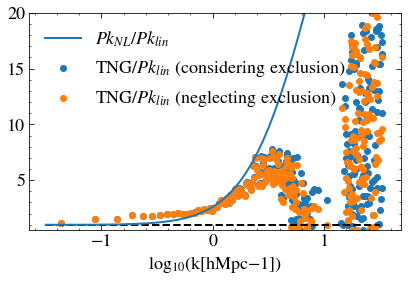

In [35]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R=0.1

plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

ratio_lin = (Pk110_group["power"].real-Pk110_group.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_lin(Pk110["k"], R=R))/Plin(Pk110["k"])
ratio_nl = (Pk110_group["power"].real-Pk110_group.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_NL(Pk110["k"], R=R))/Plin(Pk110["k"])

ratio_no_exclusion = (Pk110_group["power"].real-Pk110_group.attrs["shotnoise"])/Plin(Pk110["k"])

plt.scatter(np.log10(Pk110_group["k"]),ratio_lin, label="TNG/$Pk_{lin}$ (considering exclusion)")
plt.scatter(np.log10(Pk110_group["k"]),ratio_no_exclusion, label="TNG/$Pk_{lin}$ (neglecting exclusion)")

#plt.scatter(np.log10(Pk110_group["k"]),ratio_nl, label="TNG/$Pk_{lin}$ (assuming NL kernel)")

    
        
        
#plt.ylim(0.5,2)
plt.ylim(0.5,20)
plt.legend(loc="upper left")
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

(0.99, 1.11)

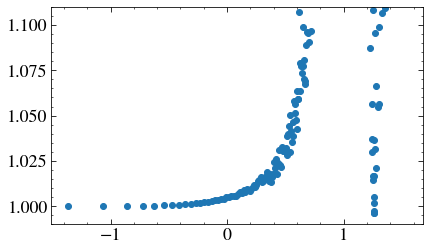

In [42]:
ratio_excl11 = ratio_lin/ratio_no_exclusion
plt.scatter(np.log10(Pk110_group["k"]), ratio_excl11)
plt.ylim(0.99,1.11)

(0.0, 2.0)

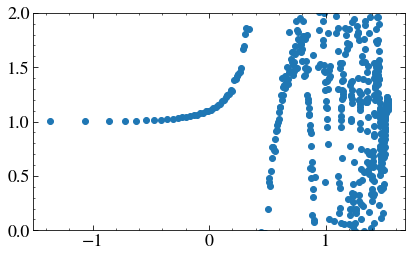

In [51]:
R = 0.5
ratio_excl = (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"] + V_excl(R)*W_R(Pk110["k"], R) + kernel_lin(Pk110["k"], R=R))/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])

plt.scatter(np.log10(Pk_sum10["k"]), ratio_excl)
plt.ylim(0,2)